In [11]:
import numpy as np
import matplotlib.pyplot as plt

from stream_perturbing_halos import (
    find_mw_halos,
    fetch_subhalos,
    perturbations_per_degree,
    population_perturbation_rates,
    MW_HALO_MASS_MSUN,
    PERTURBER_MASS_MSUN,
    PERTURBER_R_RANGE_KPC,
)

In [12]:
mw = find_mw_halos()
print(
    f"{len(mw)} MW analogs in M_central = "
    f"[{MW_HALO_MASS_MSUN[0]:.0e}, {MW_HALO_MASS_MSUN[1]:.0e}] Msun"
)
print(f"index range: {min(mw)}..{max(mw)}")
print(f"first 10: {mw[:10]}")

103 MW analogs in M_central = [1e+12, 2e+12] Msun
index range: 77..241
first 10: [77, 85, 89, 90, 95, 103, 106, 108, 112, 113]


In [13]:
sh = fetch_subhalos(mw[0])  # halo 77
for k, v in sh.items():
    print(
        f"  {k:14s} shape={getattr(v, 'shape', None)} dtype={getattr(v, 'dtype', None)}"
    )

print(f"\nN subhalos in [1e6, 1e9] Msun: {len(sh['id'])}")
print(f"M range: {sh['mass_msun'].min():.2e} to {sh['mass_msun'].max():.2e} Msun")
print(f"R range: {sh['R_kpc'].min():.2f} to {sh['R_kpc'].max():.2f} kpc")
print(f"halo center (sim coords): {sh['halo_pos_kpc']}")

  id             shape=(1275,) dtype=int64
  mass_msun      shape=(1275,) dtype=float64
  pos_kpc        shape=(1275, 3) dtype=float64
  R_kpc          shape=(1275,) dtype=float64
  halo_pos_kpc   shape=(3,) dtype=float64

N subhalos in [1e6, 1e9] Msun: 1275
M range: 9.08e+06 to 9.93e+08 Msun
R range: 40.94 to 1537.80 kpc
halo center (sim coords): [19701.51267715 45124.69264375 31624.49600495]


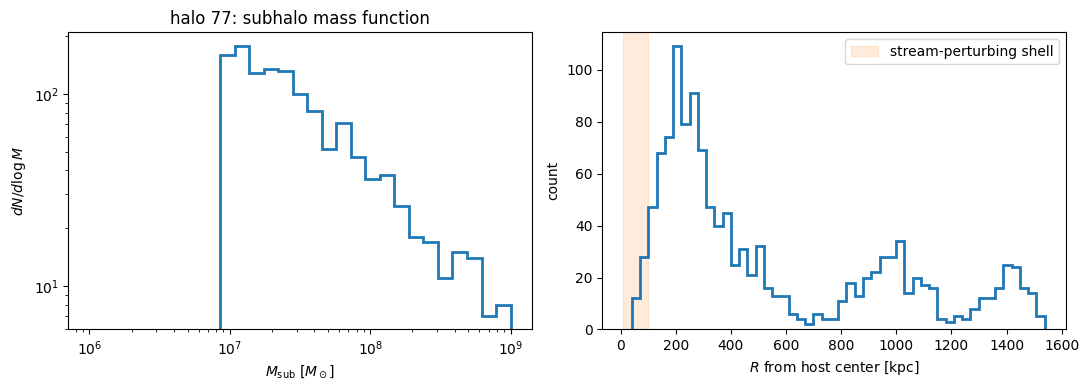

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Mass function
mbins = np.logspace(6, 9, 30)
axes[0].hist(sh["mass_msun"], bins=mbins, histtype="step", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
axes[0].set_ylabel(r"$dN/d\log M$")
axes[0].set_title(f"halo {mw[0]}: subhalo mass function")

# Radial distribution
axes[1].hist(sh["R_kpc"], bins=50, histtype="step", lw=2)
axes[1].axvspan(
    *PERTURBER_R_RANGE_KPC, color="C1", alpha=0.15, label="stream-perturbing shell"
)
axes[1].set_xlabel(r"$R$ from host center [kpc]")
axes[1].set_ylabel("count")
axes[1].legend()
plt.tight_layout()

CDM N_perturb/deg @ GD-1 (D=8 kpc, T=3 Gyr):
  median = 0.00682
  16-84% range = 0.00522 – 0.00952
  full range across 103 hosts: 0.00311 – 0.0154


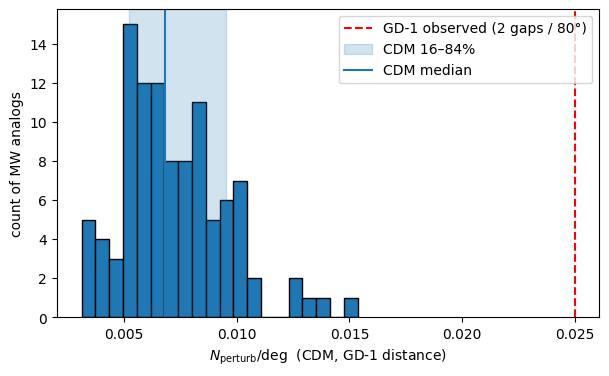

In [15]:
pop = population_perturbation_rates(stream_distance_kpc=8.0, stream_age_gyr=3.0)

med = np.median(pop["per_deg"])
p16, p84 = np.percentile(pop["per_deg"], [16, 84])
print("CDM N_perturb/deg @ GD-1 (D=8 kpc, T=3 Gyr):")
print(f"  median = {med:.3g}")
print(f"  16-84% range = {p16:.3g} – {p84:.3g}")
print(
    f"  full range across {len(pop['per_deg'])} hosts:"
    f" {pop['per_deg'].min():.3g} – {pop['per_deg'].max():.3g}"
)

# Quick distribution plot
plt.figure(figsize=(7, 4))
plt.hist(pop["per_deg"], bins=20, edgecolor="k")
plt.axvline(2 / 80, color="red", ls="--", label="GD-1 observed (2 gaps / 80°)")
plt.axvspan(p16, p84, color="C0", alpha=0.2, label="CDM 16–84%")
plt.axvline(med, color="C0", label="CDM median")
plt.xlabel(r"$N_{\rm perturb}/{\rm deg}$  (CDM, GD-1 distance)")
plt.ylabel("count of MW analogs")
plt.legend()

In [16]:
result = perturbations_per_degree(sh, stream_distance_kpc=8.0, stream_age_gyr=3.0)
for k, v in result.items():
    print(f"  {k:14s} = {v:.4g}")

  per_kpc        = 0.03622
  per_deg        = 0.005057
  n_perturbers   = 38
  V_shell_kpc3   = 4.185e+06
  rate_gyr       = 0.01207
